In [1]:
import os
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

sys.path.append("..")

from src.config import TRAIN_DIR, TEST_DIR, CLASS_NAMES
from src.utils import set_seed

In [2]:
set_seed(42)
print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)
print("Total expected classes:", len(CLASS_NAMES))

Train dir: D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data\extracted\train
Test dir: D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data\extracted\test
Total expected classes: 29


In [3]:
print("TRAIN exists:", TRAIN_DIR.exists())
print("TEST exists:", TEST_DIR.exists())

TRAIN exists: True
TEST exists: True


In [4]:
train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
print("Train classes found:", len(train_classes))
print(train_classes)

Train classes found: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [5]:
expected = set(CLASS_NAMES)
found = set(train_classes)

print("Missing classes:", sorted(expected - found))
print("Extra classes:", sorted(found - expected))

Missing classes: []
Extra classes: []


In [6]:
train_counts = {}

for class_name in train_classes:
    class_dir = TRAIN_DIR / class_name
    image_files = list(class_dir.glob("*.jpg"))
    train_counts[class_name] = len(image_files)

train_df = pd.DataFrame(
    sorted(train_counts.items()), columns=["class_name", "count"]
)
train_df

,class_name,count
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


In [7]:
print("Total train images:", train_df["count"].sum())
print("Min images/class:", train_df["count"].min())
print("Max images/class:", train_df["count"].max())

Total train images: 87000
Min images/class: 3000
Max images/class: 3000


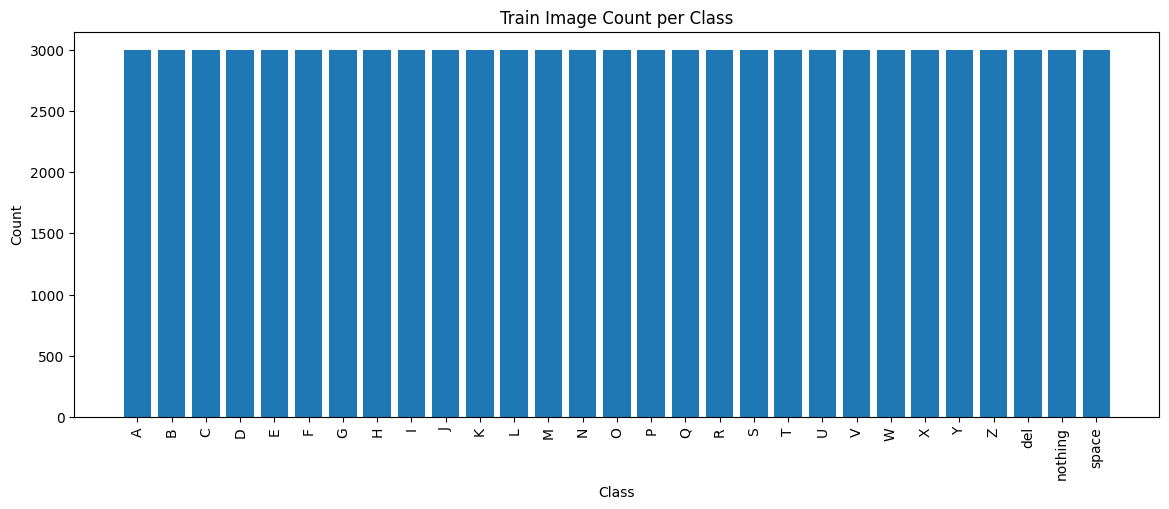

In [8]:
plt.figure(figsize=(14, 5))
plt.bar(train_df["class_name"], train_df["count"])
plt.xticks(rotation=90)
plt.title("Train Image Count per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [9]:
test_files = sorted(list(TEST_DIR.glob("*.jpg")))
print("Total test files:", len(test_files))
print([p.name for p in test_files[:10]])

Total test files: 28
['A_test.jpg', 'B_test.jpg', 'C_test.jpg', 'D_test.jpg', 'E_test.jpg', 'F_test.jpg', 'G_test.jpg', 'H_test.jpg', 'I_test.jpg', 'J_test.jpg']


In [10]:
def extract_test_label(filename):
    return filename.replace("_test.jpg", "")

test_labels = [extract_test_label(p.name) for p in test_files]
print("Test labels:", test_labels)
print("Total unique test labels:", len(set(test_labels)))

Test labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'nothing', 'O', 'P', 'Q', 'R', 'S', 'space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total unique test labels: 28


In [11]:
print("Missing from test (compared to train classes):", sorted(set(CLASS_NAMES) - set(test_labels)))
print("Extra in test:", sorted(set(test_labels) - set(CLASS_NAMES)))

Missing from test (compared to train classes): ['del']
Extra in test: []


In [13]:
sample_paths = [
    next((TRAIN_DIR / train_classes[0]).glob("*.jpg")),
    test_files[0]
]

for path in sample_paths:
    with Image.open(path) as img:
        print(path.name, "| size:", img.size, "| mode:", img.mode, "| format:", img.format)

A1.jpg | size: (200, 200) | mode: RGB | format: JPEG
A_test.jpg | size: (200, 200) | mode: RGB | format: JPEG


In [14]:
bad_files = []

for class_name in train_classes:
    for img_path in (TRAIN_DIR / class_name).glob("*.jpg"):
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            bad_files.append(str(img_path))

for img_path in test_files:
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        bad_files.append(str(img_path))

print("Total corrupt files:", len(bad_files))
bad_files[:10]

Total corrupt files: 0


[]

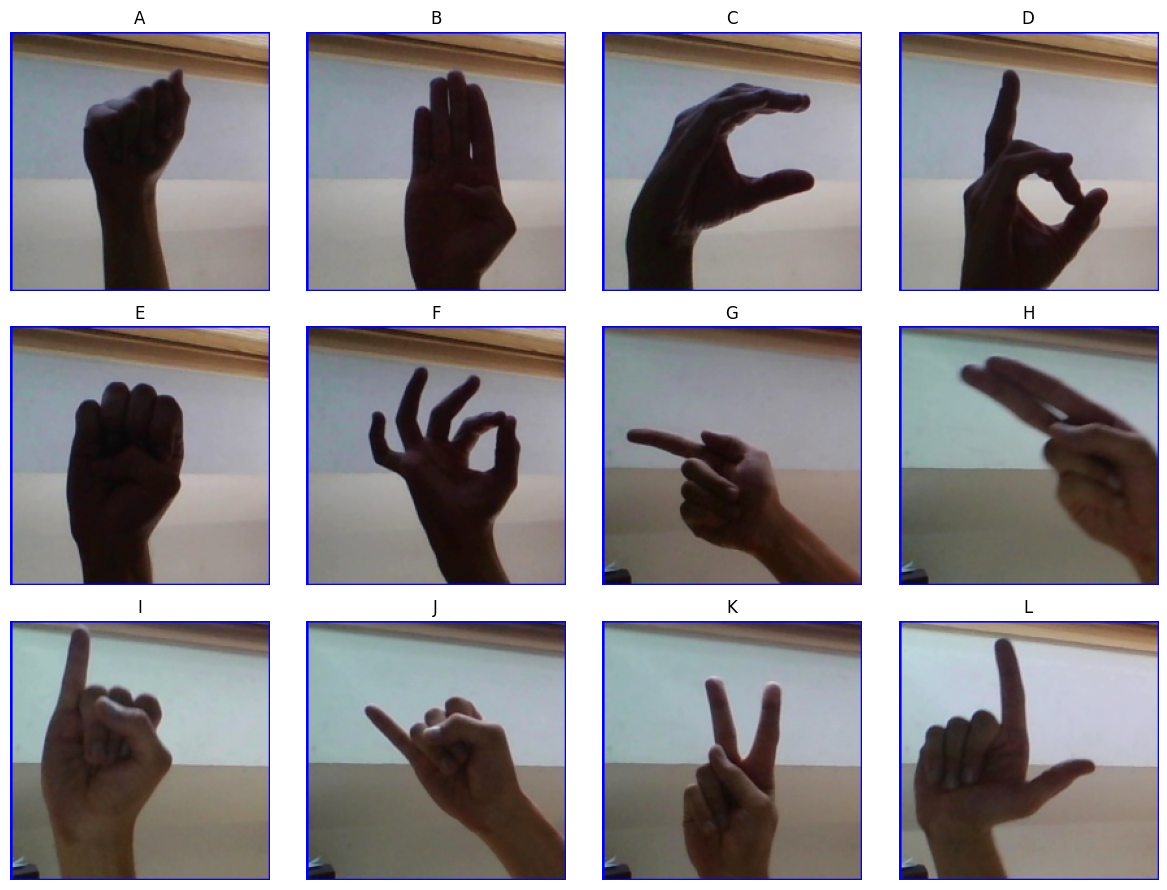

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
sample_classes = train_classes[:12]

for ax, class_name in zip(axes.flatten(), sample_classes):
    img_path = next((TRAIN_DIR / class_name).glob("*.jpg"))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

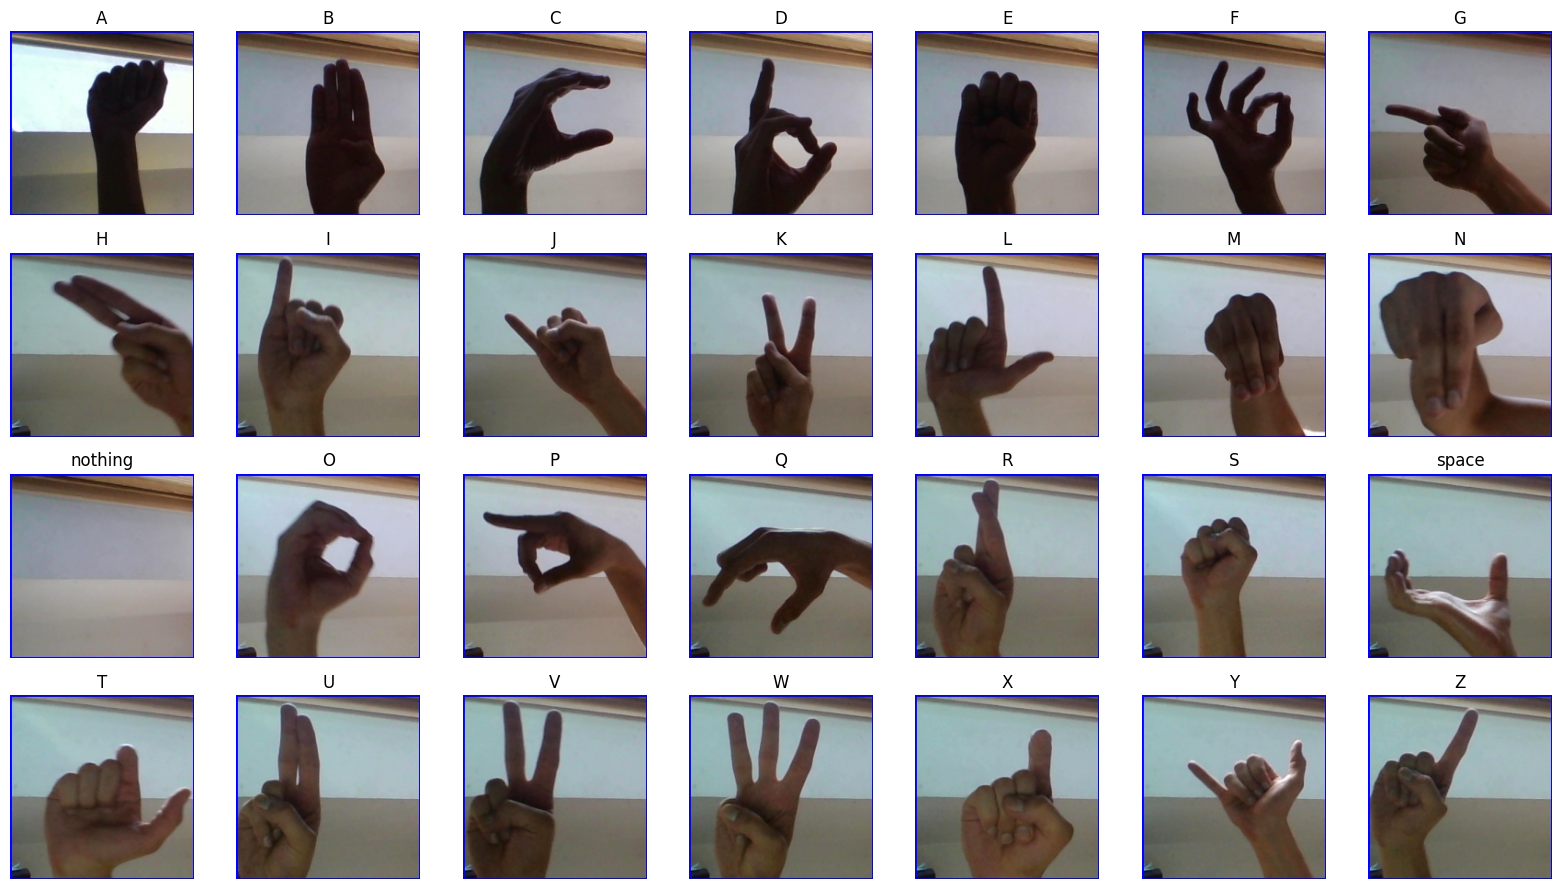

In [16]:
fig, axes = plt.subplots(4, 7, figsize=(16, 9))

for ax, img_path in zip(axes.flatten(), test_files):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(extract_test_label(img_path.name))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
print("===== DATASET AUDIT SUMMARY =====")
print(f"Train classes found      : {len(train_classes)}")
print(f"Train total images       : {train_df['count'].sum()}")
print(f"Test total images        : {len(test_files)}")
print(f"Balanced train set       : {train_df['count'].nunique() == 1}")
print(f"Test missing label(s)    : {sorted(set(CLASS_NAMES) - set(test_labels))}")
print(f"Corrupt files            : {len(bad_files)}")

===== DATASET AUDIT SUMMARY =====
Train classes found      : 29
Train total images       : 87000
Test total images        : 28
Balanced train set       : True
Test missing label(s)    : ['del']
Corrupt files            : 0


In [18]:
from src.data_loader import get_dataframes, summarize_dataframe

train_df, val_df = get_dataframes()

print(train_df.head())
print(val_df.head())

train_summary = summarize_dataframe(train_df, "train split")
val_summary = summarize_dataframe(val_df, "val split")

                                            filepath label
0  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     A
1  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     Y
2  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     Z
3  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     Z
4  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     H
                                            filepath label
0  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     I
1  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     K
2  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     N
3  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     O
4  D:\Darryl\CODING DARRYL\IRIS\SHORT-TERM-1\data...     X

===== SUMMARY: TRAIN SPLIT =====
Total samples: 69600
  label  count
      A   2400
      B   2400
      C   2400
      D   2400
      E   2400
      F   2400
      G   2400
      H   2400
      I   2400
      J   2400
      K   2400
      L   2400
      M   2400
      N   2400
      O   24